# Qwen2.5 Quantization Theoretical-Limit Heatmaps

This notebook computes theoretical Naive Method I and Naive Method II limits for the Qwen2.5-14B quantization/loading experiment.

Load modes are treated as the three compared models:

- `bf16`
- `8bit`
- `4bit`

For each reference load mode A, the notebook evaluates all suspect load modes B under four deterministic random decoding conditions:

1. two conditions with random `(temperature, top_p, logit_bias)`;
2. two conditions with random `(temperature, logit_bias)` and fixed `top_p = 1`.

The notebook produces 8 total 3x3 heatmaps: 4 decoding conditions times 2 naive estimators. Rows are reference load modes A, columns are suspect load modes B, and the diagonal should be zero whenever the estimator is defined. Gray `N/A` cells mean the estimator is undefined, typically because top-p removed one of the target tokens or because a denominator vanished.


In [1]:
from pathlib import Path
import os
import sys

# Prevent a Windows/conda OpenMP duplicate-runtime crash when torch/matplotlib are imported together.
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.colors import PowerNorm

cwd = Path.cwd().resolve()
if (cwd / 'logit_helpers.py').exists():
    REPO_ROOT = cwd
elif (cwd.parent / 'logit_helpers.py').exists():
    REPO_ROOT = cwd.parent
else:
    raise RuntimeError('Could not find repo root containing logit_helpers.py')

sys.path.insert(0, str(REPO_ROOT))

from logit_helpers import (
    RANDOM_DECODING_LOGIT_BIAS_RANGE,
    RANDOM_DECODING_TEMPERATURE_RANGE,
    RandomDecodingParams,
    make_probability_vector,
    make_random_decoding_params,
)
from estimators import naive_method_i_estimator, naive_method_ii_estimator

PAYLOAD_DIR = REPO_ROOT / 'quantization_level_experiment' / 'logit_payloads'
print('REPO_ROOT:', REPO_ROOT)
print('PAYLOAD_DIR:', PAYLOAD_DIR)


REPO_ROOT: C:\Users\beatn\LLM-Ownership-Identification-Draft-1
PAYLOAD_DIR: C:\Users\beatn\LLM-Ownership-Identification-Draft-1\quantization_level_experiment\logit_payloads


## Experiment Configuration

The canary prompts are exactly the primary 14B canaries: `C1 = prompt 1`, `C2 = C3 = prompt 4`, and `C4 = prompt 5`.


In [2]:
LOAD_MODES = ('bf16', '8bit', '4bit')
LOAD_MODE_LABELS = {
    'bf16': 'bf16',
    '8bit': '8bit',
    '4bit': '4bit',
}
FILE_PREFIXES = {mode: f'qwen25_14b_{mode}' for mode in LOAD_MODES}

CANARY_PROMPTS = {
    1: 1,  # C1 = prompt 1
    2: 4,  # C2 = C3 = prompt 4
    4: 5,  # C4 = prompt 5
}

TOKEN_A = 15  # token string '0'
TOKEN_B = 16  # token string '1'

print('Load modes:', LOAD_MODES)
print('Canary prompt mapping:', CANARY_PROMPTS)


Load modes: ('bf16', '8bit', '4bit')
Canary prompt mapping: {1: 1, 2: 4, 4: 5}


## Generate Four Reproducible Decoding Conditions


In [3]:
params_top_p_1 = make_random_decoding_params(seed=20261094, tokens_to_bias=(TOKEN_A, TOKEN_B))
params_top_p_2 = make_random_decoding_params(seed=20260996, tokens_to_bias=(TOKEN_A, TOKEN_B))
params_no_top_p_1_base = make_random_decoding_params(seed=20260724, tokens_to_bias=(TOKEN_A, TOKEN_B))
params_no_top_p_2_base = make_random_decoding_params(seed=20260729, tokens_to_bias=(TOKEN_A, TOKEN_B))

DECODING_CONDITIONS = {
    'Random Decoding Parameter Config 1': params_top_p_1,
    'Random Decoding Parameter Config 2': params_top_p_2,
    'Random Decoding Parameter Config 3': RandomDecodingParams(
        temperature=params_no_top_p_1_base.temperature,
        top_p=1.0,
        logit_bias=params_no_top_p_1_base.logit_bias,
        seed=params_no_top_p_1_base.seed,
    ),
    'Random Decoding Parameter Config 4': RandomDecodingParams(
        temperature=params_no_top_p_2_base.temperature,
        top_p=1.0,
        logit_bias=params_no_top_p_2_base.logit_bias,
        seed=params_no_top_p_2_base.seed,
    ),
}

TOKEN_LABELS = {
    TOKEN_A: '0',
    TOKEN_B: '1',
}


def format_logit_bias(params: RandomDecodingParams) -> str:
    entries = [
        f'"{TOKEN_LABELS.get(token_id, str(token_id))}": {bias:g}'
        for token_id, bias in params.logit_bias.items()
    ]
    return '{' + ', '.join(entries) + '}'


def format_decoding_config_title(condition_name: str, params: RandomDecodingParams) -> str:
    return (
        f'{condition_name}\n'
        f'T={params.temperature:.3g}, top_p={params.top_p:.3g}, '
        f'bias={format_logit_bias(params)}'
    )


for name, params in DECODING_CONDITIONS.items():
    print(
        name,
        f'temperature={params.temperature:.12g}',
        f'top_p={params.top_p:.12g}',
        f'logit_bias={format_logit_bias(params)}',
        f'seed={params.seed}',
    )


Random Decoding Parameter Config 1 temperature=0.979487739621 top_p=0.943088983308 logit_bias={"0": 1, "1": 2} seed=20261094
Random Decoding Parameter Config 2 temperature=1.02979525831 top_p=0.94762802487 logit_bias={"0": -2, "1": -1} seed=20260996
Random Decoding Parameter Config 3 temperature=0.904171607961 top_p=1 logit_bias={"0": -2, "1": -1} seed=20260724
Random Decoding Parameter Config 4 temperature=0.857640421203 top_p=1 logit_bias={"0": 1, "1": 1} seed=20260729


## Core Computation


In [4]:
def payload_path(load_mode: str, prompt_id: int) -> Path:
    return PAYLOAD_DIR / f'{FILE_PREFIXES[load_mode]}_prompt_{prompt_id}_logits.pt'


def load_logits(load_mode: str, prompt_id: int) -> np.ndarray:
    path = payload_path(load_mode, prompt_id)
    if not path.exists():
        raise FileNotFoundError(f'Missing payload: {path}')
    payload = torch.load(path, map_location='cpu')
    logits = payload['logits'].detach().cpu().numpy().astype(np.float64, copy=False)
    if logits.ndim != 1:
        raise ValueError(f'Expected 1D logits for {load_mode} prompt {prompt_id}; got {logits.shape}')
    return logits


def reference_z_dictionary(reference_mode: str) -> dict[tuple[int, int], float]:
    z = {}
    for slot, prompt_id in CANARY_PROMPTS.items():
        logits = load_logits(reference_mode, prompt_id)
        z[(slot, 0)] = float(logits[TOKEN_A])
        z[(slot, 1)] = float(logits[TOKEN_B])
    return z


def decoded_g_dictionary(suspect_mode: str, params: RandomDecodingParams) -> tuple[dict[int, float], dict[int, str]]:
    g = {}
    status = {}
    for slot, prompt_id in CANARY_PROMPTS.items():
        logits = load_logits(suspect_mode, prompt_id)
        probs = make_probability_vector(
            logits,
            temperature=params.temperature,
            logit_bias=params.logit_bias,
            top_p=params.top_p,
        )
        p_a = float(probs[TOKEN_A])
        p_b = float(probs[TOKEN_B])
        if p_a <= 0.0 or p_b <= 0.0:
            g[slot] = np.nan
            status[slot] = f'undefined: p_a={p_a:.3g}, p_b={p_b:.3g}'
        else:
            g[slot] = float(np.log(p_a) - np.log(p_b))
            status[slot] = 'ok'
    return g, status


METHODS = {
    'Naive Method I': naive_method_i_estimator,
    'Naive Method II': naive_method_ii_estimator,
}

records = []
for reference_mode in LOAD_MODES:
    z = reference_z_dictionary(reference_mode)
    for condition_name, params in DECODING_CONDITIONS.items():
        for method_name, estimator_fn in METHODS.items():
            for suspect_mode in LOAD_MODES:
                g, status = decoded_g_dictionary(suspect_mode, params)
                value = float(estimator_fn(z, g))
                records.append({
                    'reference_mode': reference_mode,
                    'suspect_mode': suspect_mode,
                    'condition_name': condition_name,
                    'method_name': method_name,
                    'value': value,
                    'g': g,
                    'status': status,
                    'params': params,
                })

print('records:', len(records))


records: 72


## Numeric Table and Diagonal Sanity Check


In [5]:
def fmt(value: float) -> str:
    if not np.isfinite(value):
        return 'N/A'
    return f'{value:.6g}'

print('Theoretical limits')
header = f"{'A':<6} {'B':<6} {'condition':<16} {'method':<16} {'value':>14}"
print(header)
print('-' * len(header))
for record in records:
    print(
        f"{record['reference_mode']:<6} {record['suspect_mode']:<6} "
        f"{record['condition_name']:<16} {record['method_name']:<16} "
        f"{fmt(record['value']):>14}"
    )

DIAGONAL_TOLERANCE = 1e-9
bad_diagonals = []
for record in records:
    if record['reference_mode'] == record['suspect_mode']:
        value = record['value']
        if np.isfinite(value) and abs(value) > DIAGONAL_TOLERANCE:
            bad_diagonals.append(record)

print('\nfinite diagonal entries checked:', sum(
    1 for record in records
    if record['reference_mode'] == record['suspect_mode'] and np.isfinite(record['value'])
))
if bad_diagonals:
    print('WARNING: nonzero finite diagonal entries found')
    for record in bad_diagonals:
        print(record['reference_mode'], record['condition_name'], record['method_name'], record['value'])
else:
    print('All finite diagonal entries are within tolerance of zero.')


Theoretical limits
A      B      condition        method                    value
--------------------------------------------------------------
bf16   bf16   Random Decoding Parameter Config 1 Naive Method I      2.77556e-15
bf16   8bit   Random Decoding Parameter Config 1 Naive Method I          6.07282
bf16   4bit   Random Decoding Parameter Config 1 Naive Method I         0.228547
bf16   bf16   Random Decoding Parameter Config 1 Naive Method II     1.44329e-15
bf16   8bit   Random Decoding Parameter Config 1 Naive Method II           -4.65
bf16   4bit   Random Decoding Parameter Config 1 Naive Method II        0.641667
bf16   bf16   Random Decoding Parameter Config 2 Naive Method I      8.88178e-16
bf16   8bit   Random Decoding Parameter Config 2 Naive Method I          6.38473
bf16   4bit   Random Decoding Parameter Config 2 Naive Method I         0.240286
bf16   bf16   Random Decoding Parameter Config 2 Naive Method II     4.44089e-16
bf16   8bit   Random Decoding Parameter Confi

## Heatmaps


Saved PNG export: C:\Users\beatn\LLM-Ownership-Identification-Draft-1\assets\quantization_theoretical_limit_heatmaps.png


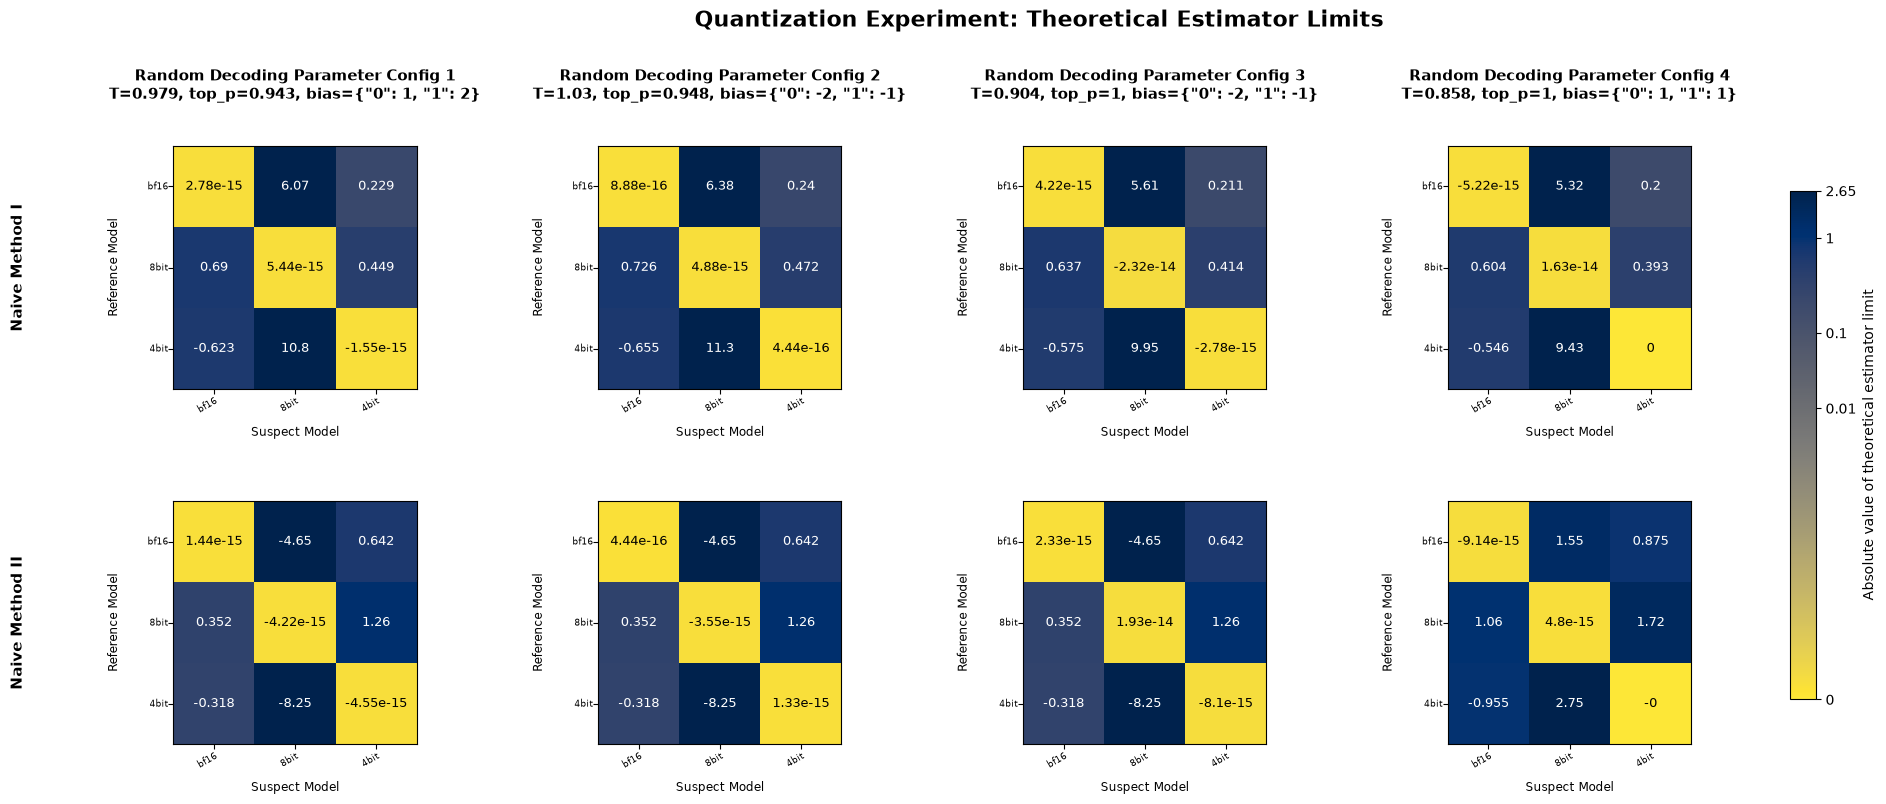

In [6]:
def value_matrix(condition_name: str, method_name: str) -> np.ndarray:
    matrix = np.full((len(LOAD_MODES), len(LOAD_MODES)), np.nan, dtype=np.float64)
    for record in records:
        if record['condition_name'] == condition_name and record['method_name'] == method_name:
            row = LOAD_MODES.index(record['reference_mode'])
            col = LOAD_MODES.index(record['suspect_mode'])
            matrix[row, col] = record['value']
    return matrix


finite_values = np.array([record['value'] for record in records if np.isfinite(record['value'])], dtype=np.float64)
finite_abs_values = np.abs(finite_values)
finite_abs_values = finite_abs_values[finite_abs_values > 1e-10]

# -----------------------------
# Fast visual tuning knobs
# -----------------------------
# Any matplotlib colormap name works here. The `_r` suffix reverses it.
# Default: 'cividis_r' makes near-zero light/yellow and large distance dark/blue.
# Useful options: 'cividis_r', 'viridis_r', 'magma_r', 'YlGnBu'.
HEATMAP_COLORMAP = 'cividis_r'

# Controls how aggressively distance-from-zero changes color.
# 1.0 = linear. Smaller values make small nonzero distances light up faster.
# Try 0.1, 0.35, 0.50, 0.75, or 1.0.
COLOR_CHANGE_ACCELERATION = 0.1

# Clips extreme off-diagonal values so the whole grid does not get visually flattened.
# Lower percentile = more saturation; higher percentile = less saturation.
COLOR_LIMIT_PERCENTILE = 70.0

# Neutral color for undefined cells. Kept separate from the near-zero dark-blue color.
N_A_CELL_COLOR = '#d1d5db'

if finite_abs_values.size:
    color_abs_max = float(np.percentile(finite_abs_values, COLOR_LIMIT_PERCENTILE))
else:
    color_abs_max = 1.0
color_abs_max = max(color_abs_max, 1e-12)

# Color encodes distance from zero, not sign. The signed estimator value is still
# printed inside each cell.
norm = PowerNorm(
    gamma=COLOR_CHANGE_ACCELERATION,
    vmin=0.0,
    vmax=color_abs_max,
)
cmap = plt.get_cmap(HEATMAP_COLORMAP).copy()
cmap.set_bad(color=N_A_CELL_COLOR)


def readable_text_color(background_rgba) -> str:
    """Return black or white text based on perceived background brightness."""
    red, green, blue, _alpha = background_rgba
    linear = []
    for channel in (red, green, blue):
        if channel <= 0.03928:
            linear.append(channel / 12.92)
        else:
            linear.append(((channel + 0.055) / 1.055) ** 2.4)
    luminance = 0.2126 * linear[0] + 0.7152 * linear[1] + 0.0722 * linear[2]
    return 'black' if luminance > 0.45 else 'white'


condition_order = tuple(DECODING_CONDITIONS.keys())
method_order = tuple(METHODS.keys())
axis_labels = [LOAD_MODE_LABELS[mode] for mode in LOAD_MODES]

fig, axes = plt.subplots(
    nrows=len(method_order),
    ncols=len(condition_order),
    figsize=(22.8, 8.8),
    constrained_layout=False,
)
fig.subplots_adjust(left=0.06, right=0.93, top=0.82, bottom=0.14, wspace=0.36, hspace=0.46)
fig.suptitle(
    'Quantization Experiment: Theoretical Estimator Limits',
    x=0.47,
    y=0.975,
    fontsize=16,
    fontweight='bold',
)

last_image = None
for row_idx, method_name in enumerate(method_order):
    for col_idx, condition_name in enumerate(condition_order):
        ax = axes[row_idx, col_idx]
        matrix = value_matrix(condition_name, method_name)
        color_matrix = np.abs(matrix)
        masked = np.ma.masked_invalid(color_matrix)
        last_image = ax.imshow(masked, cmap=cmap, norm=norm)

        ax.set_xticks(range(len(LOAD_MODES)), axis_labels, rotation=30, ha='right')
        ax.set_yticks(range(len(LOAD_MODES)), axis_labels)
        ax.tick_params(axis='x', labelsize=6.5, pad=1)
        ax.tick_params(axis='y', labelsize=6.5, pad=0)
        for tick_label in ax.get_xticklabels():
            tick_label.set_rotation_mode('anchor')
        for tick_label in ax.get_yticklabels():
            tick_label.set_rotation(0)
            tick_label.set_ha('right')
            tick_label.set_va('center')
            tick_label.set_rotation_mode('anchor')
        if row_idx == 0:
            ax.set_title(
                format_decoding_config_title(condition_name, DECODING_CONDITIONS[condition_name]),
                fontsize=11,
                fontweight='bold',
                pad=34,
            )
        ax.set_xlabel('Suspect Model', labelpad=8, fontsize=8.5)
        ax.set_ylabel('Reference Model', fontsize=8.5)
        ax.yaxis.set_label_coords(-0.22, 0.5)

        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                value = matrix[i, j]
                if not np.isfinite(value):
                    label = 'N/A'
                    background_rgba = cmap.get_bad()
                else:
                    label = f'{value:.3g}'
                    background_rgba = cmap(norm(abs(value)))
                text_color = readable_text_color(background_rgba)
                ax.text(j, i, label, ha='center', va='center', fontsize=9, color=text_color)

for row_idx, method_name in enumerate(method_order):
    row_axes = axes[row_idx, :]
    y_center = sum(ax.get_position().y0 + ax.get_position().height / 2 for ax in row_axes) / len(row_axes)
    fig.text(
        0.022,
        y_center,
        method_name,
        va='center',
        ha='center',
        rotation='vertical',
        fontsize=11,
        fontweight='bold',
    )


cbar = fig.colorbar(last_image, ax=axes.ravel().tolist(), shrink=0.85)
cbar.set_label('Absolute value of theoretical estimator limit')

# Keep the symmetric-log colorbar readable without hiding the sub-1 region.
# The exact cell values are printed inside the heatmap; these ticks are just visual anchors.
tick_candidates = [0.0, 0.01, 0.1, 1.0, color_abs_max]
colorbar_ticks = [tick for tick in tick_candidates if 0.0 <= tick <= color_abs_max]
unique_ticks = []
for tick in colorbar_ticks:
    if not any(np.isclose(tick, seen, rtol=0.0, atol=1e-12) for seen in unique_ticks):
        unique_ticks.append(tick)
cbar.set_ticks(unique_ticks)
cbar.set_ticklabels([f'{tick:.3g}' for tick in unique_ticks])
ASSET_DIR = REPO_ROOT / 'assets'
ASSET_DIR.mkdir(exist_ok=True)
fig.savefig(ASSET_DIR / 'quantization_theoretical_limit_heatmaps.png', dpi=300, bbox_inches='tight')
print('Saved PNG export:', ASSET_DIR / 'quantization_theoretical_limit_heatmaps.png')
plt.show()
